<a href="https://colab.research.google.com/github/flynnight/Tubes-Siscer/blob/main/ML_Medical_Insurance_Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perbandingan KNN dan DT Untuk Memprediksi Biaya Asuransi Kesehatan Menggunakan Variabel Smoker dan Age**

---
> **Level 2: AI-Assisted Idea Generation & Structuring**
---

## **1. Topik & Identitas**

Judul Studi Kasus: Perbandingan KNN dan Decision Tree Untuk Estimasi Biaya Asuransi Kesehatan Menggunakan Fitur Smoker dan Age

| Nama | NIM |
|------|-----|
| Fathahul Rizqa Arrahman | 103032430013 |
| Febriani Zahra | 103032400034 |
| Muhammad Maulana Darmawansyah | 103032400081 |



---
## 📦 Instalasi & Import Library

In [523]:
#untuk membaca dan mengolah dataset dalam bentuk tabel
import pandas as pd
#untuk operasi matematika dll
import numpy as np

#untuk membuat grafik (x, y)
import matplotlib.pyplot as plt
#untuk scatter plot
import matplotlib.ticker as mticker
#untuk memperjelas grafik yang dibuat oleh matplotlib
import seaborn as sns

#mengubah data teks menjadi angka
from sklearn.preprocessing import LabelEncoder
#menyamakan skala data
from sklearn.preprocessing import StandardScaler

#untuk melakukan cross validation
from sklearn.model_selection import KFold
#mencari parameter yang terbaik secara otomatis
from sklearn.model_selection import GridSearchCV
#menghasilkan prediksi dengan cross validation
from sklearn.model_selection import cross_val_predict
#untuk R^2 Score
from sklearn.model_selection import cross_val_score

#model KNN untuk regresi
from sklearn.neighbors import KNeighborsRegressor
#model DT untuk regresi
from sklearn.tree import DecisionTreeRegressor

#berguna untuk mengukur kualitas dari model yang dipake
from sklearn.metrics import (
    #MAE (mean_absolute_error) berguna untuk menghitung rata-rata selisih absolut antara nilai sebenernya dengan nilai prediksi
    mean_absolute_error,
    #RMSE (root_mean_squared_error) berguna untuk menghitung akar kuadrat dari rata-rata selisih kuadrat antara nilai sebenernya dengan nilai prediksi
    mean_squared_error,
    #r2_score untuk mengukur seberapa besar variasi data yang dapat dijelaskan oleh model
    r2_score,
    #MAPE untuk mengukur kesalahan prediksi dalam persentase
    mean_absolute_percentage_error
)

#Digunakan untuk mengimpor fungsi sqrt() dari library bawaan Python math dan sqrt adalah singkatan dari Square Root (akar kuadrat)
from math import sqrt

from scipy import stats
from scipy.stats import pointbiserialr
from scipy.stats import f_oneway
print('Semua library berhasil diimport!')

Semua library berhasil diimport!


---
## Load Dataset

> **Cara upload dataset:**  
> 1. Download file `insurance.csv` dari [Kaggle](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)  
> 2. Upload ke Google Colab menggunakan cell di bawah

In [524]:
#untuk membaca file yang ada didalam kolom menggunakan fungsi pandas dan menyimpannya ke dalam variabel df
df = pd.read_csv('insurance.csv')

#untuk menampilkan jumlah baris dan kolom yang ada di variabel df
print("Shape:", df.shape)
#untuk menampilkan 5 baris pertama yang ada didataset
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---
## **2. Pendahuluan & Pemaparan Data**

### **2.1. Latar Belakang & Rumusan Masalah**

Biaya asuransi kesehatan dipengaruhi oleh berbagai faktor seperti usia, BMI, dan kebiasaan merokok. Oleh karena itu dilakukan perbandingan algoritma KNN dan Decision Tree untuk memprediksi biaya asuransi kesehatan.

**Rumusan Masalah:** Bagaimana perbandingan kinerja algoritma KNN dan Decision Tree dalam mengestimasi biaya asuransi kesehatan menggunakan faktor usia dan status perokok?

**Tujuan Penelitian:** Membandingkan kinerja algoritma K-Nearest Neighbor (KNN) dan Decision Tree dalam mengestimasi biaya asuransi kesehatan menggunakan faktor usia dan status perokok.

**Target Variabel:** `charges` (kontinu, USD), ini adalah **masalah REGRESI**.


### **2.2. Deskripsi Dataset**

**Deskripsi Dataset**

"Machine Learning with R by Brett Lantz is a book that provides an introduction to machine learning using R. As far as I can tell, Packt Publishing does not make its datasets available online unless you buy the book and create a user account which can be a problem if you are checking the book out from the library or borrowing the book from a friend. All of these datasets are in the public domain but simply needed some cleaning up and recoding to match the format in the book."

**Sumber Dataset:** [Kaggle - Medical Cost Personal Datasets](https://www.kaggle.com/code/fredericksalazar/linear-regresion-medical-charges-insurance/input)

In [525]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [526]:
# Encode data object
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [527]:
# Statistik Deskriptif
#untuk menampilkan statistik deskriptif
df.describe().round(2)

,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338.00,1338.00,1338.00,1338.0,1338.00,1338.00
mean,39.21,0.51,30.66,1.09,0.2,1.52,13270.42
std,14.05,0.50,6.10,1.21,0.4,1.10,12110.01
min,18.00,0.00,15.96,0.00,0.0,0.00,1121.87
25%,27.00,0.00,26.30,0.00,0.0,1.00,4740.29
50%,39.00,1.00,30.40,1.00,0.0,2.00,9382.03
75%,51.00,1.00,34.69,2.00,0.0,2.00,16639.91
max,64.00,1.00,53.13,5.00,1.0,3.00,63770.43


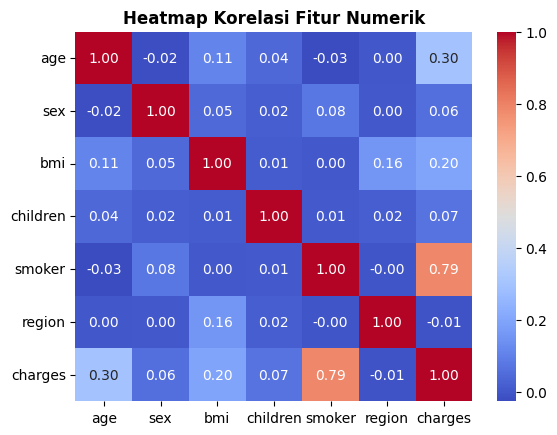

In [528]:
# Heatmap Korelasi
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,      #menampilkan angka
    fmt='.2f',       #format desimal
    cmap='coolwarm', #warna
)

plt.title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
plt.show()

### **2.1 Justifikasi Penambahan Fitur**

**BMI**

Berdasarkan hasil analisis korelasi Pearson, fitur BMI menunjukkan nilai korelasi sebesar r = 0.20 terhadap variabel target charges. Nilai ini berada pada kategori **small effect** menurut threshold Cohen (1988), yaitu r ≥ 0.10.

Meskipun tidak mencapai threshold medium (r ≥ 0.30) seperti age dan smoker, penambahan BMI tetap dipertimbangkan dengan alasan berikut:

1. Performa model dengan dua fitur (age dan smoker) menghasilkan R² maksimal ~0.71, yang masih tergolong moderat.
2. BMI merupakan faktor medis yang secara domain knowledge diketahui berpengaruh terhadap biaya kesehatan.
3. Threshold diturunkan ke small effect (r ≥ 0.10) sebagai upaya eksplorasi peningkatan performa model.

Dengan demikian, fitur input diperbarui menjadi tiga variabel: **age**, **smoker**, dan **bmi**.

**Children**

Fitur children (jumlah tanggungan) ditambahkan berdasarkan pertimbangan domain knowledge. Secara logis, semakin banyak tanggungan dalam satu polis asuransi, semakin besar potensi klaim kesehatan yang diajukan sehingga berpengaruh terhadap besaran premi.

Meskipun nilai korelasi Pearson children terhadap charges hanya sebesar r = 0.07 (di bawah threshold small effect r ≥ 0.10), penambahan fitur ini tetap dipertimbangkan karena:

1. Korelasi linear rendah tidak berarti tidak ada hubungan — bisa jadi hubungannya non-linear
2. Secara domain knowledge asuransi kesehatan, jumlah tanggungan adalah faktor umum yang dipertimbangkan dalam penentuan premi
3. Penambahan ini bersifat eksploratif untuk menguji apakah children memberikan kontribusi nyata terhadap performa model

Dengan demikian, fitur input diperbarui menjadi: **age, smoker, bmi, bmi_smoker, children**.

---
## 3. **Pra-Pemrosesan Data**
Pada tahap pra-pemrosesan data dilakukan seleksi fitur berdasarkan hasil analisis korelasi, yaitu usia (age) dan status perokok (smoker) sebagai variabel input serta biaya asuransi (charges) sebagai variabel target. Selanjutnya, variabel kategorikal smoker dikonversi menjadi data numerik menggunakan LabelEncoder. Data kemudian dipisahkan menjadi variabel input dan target, serta dilakukan normalisasi menggunakan StandardScaler untuk menyesuaikan skala data sebelum proses pelatihan model. Terakhir, digunakan metode K-Fold Cross Validation sebanyak 5 fold untuk memperoleh hasil evaluasi yang lebih reliabel.

### **3.1. Pembersihan Data (Cleaning)**
Dilakukan pemeriksaan missing values pada dataset menggunakan fungsi isnull().sum(). Hasil pemeriksaan menunjukkan bahwa tidak terdapat data yang hilang sehingga tidak diperlukan proses imputasi atau penghapusan data.

In [529]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### **3.2. Transformasi Data**
Variabel smoker yang berbentuk kategorikal (yes/no) diubah menjadi bentuk numerik menggunakan LabelEncoder agar dapat diproses oleh algoritma machine learning.

Data kemudian dinormalisasi menggunakan StandardScaler untuk menyamakan skala antar fitur sehingga tidak terjadi dominasi fitur tertentu pada proses pembelajaran model.

Rumus Normalisasi:

$$z = \frac{x - \mu}{\sigma}$$

Keterangan:


* x = nilai data
* μ = rata-rata data
* σ = standar deviasi

#### **3.2.1 Log Transformasi Target (Charges)**

Berdasarkan hasil diagnostik, variabel target charges memiliki skewness sebesar 1.51 yang tergolong right-skewed. Kondisi ini menyebabkan model kesulitan mempelajari pola pada rentang charges tinggi karena distribusi data tidak simetris.

Untuk mengatasi hal ini, diterapkan transformasi logaritma natural pada variabel target:

$$y' = \ln(\text{charges})$$

Transformasi ini bertujuan untuk:
1. Mengurangi skewness sehingga distribusi mendekati normal
2. Memperkecil pengaruh nilai ekstrem (charges sangat tinggi)
3. Membantu model belajar pola secara lebih merata di seluruh rentang nilai

Setelah prediksi dilakukan, nilai hasil prediksi dikembalikan ke skala asli menggunakan fungsi eksponensial:

$$\text{charges} = e^{y'}$$

Skewness sebelum log transform : 1.5142
Skewness sesudah log transform  : -0.0900


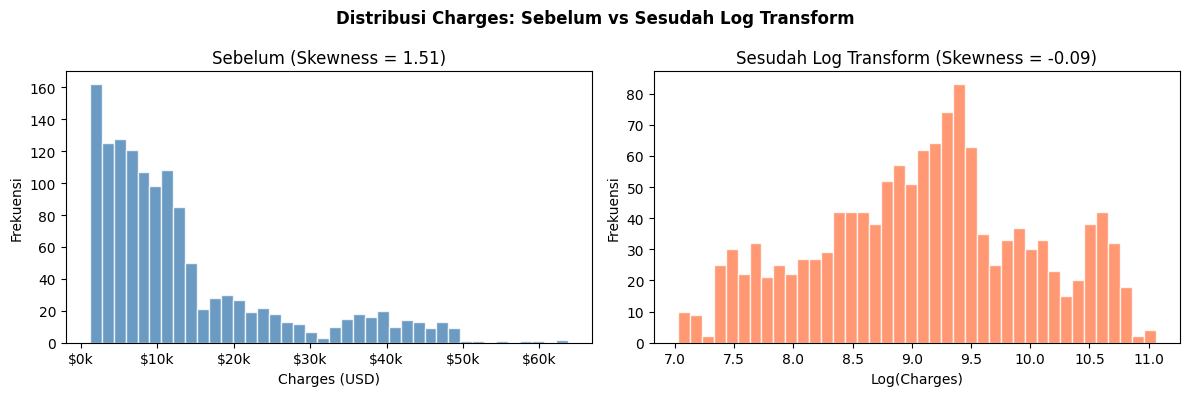

In [530]:
y_log = np.log(df['charges'])

# Cek skewness sebelum dan sesudah
from scipy.stats import skew
print(f"Skewness sebelum log transform : {skew(df['charges']):.4f}")
print(f"Skewness sesudah log transform  : {skew(y_log):.4f}")

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Charges: Sebelum vs Sesudah Log Transform', fontweight='bold')

axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Sebelum (Skewness = {skew(df["charges"]):.2f})')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

axes[1].hist(y_log, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Sesudah Log Transform (Skewness = {skew(y_log):.2f})')
axes[1].set_xlabel('Log(Charges)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

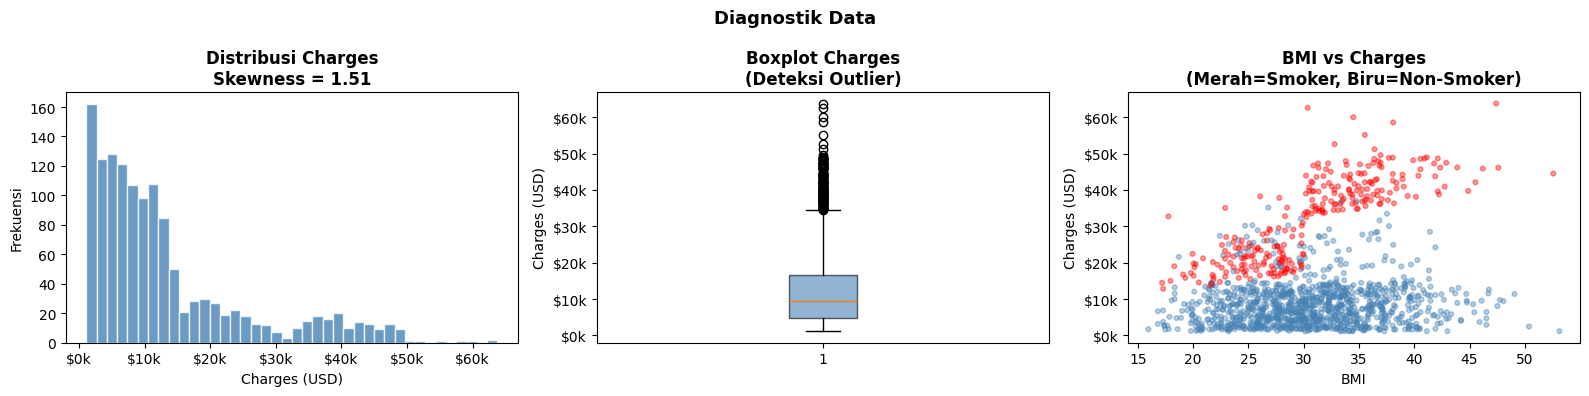

Skewness charges : 1.5142
Jumlah outlier   : 139 dari 1338 data (10.4%)
Range charges    : $1,122 – $63,770


In [531]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Diagnostik Data', fontsize=13, fontweight='bold')

# 1. Distribusi charges
skewness = skew(df['charges'])
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Distribusi Charges\nSkewness = {skewness:.2f}', fontweight='bold')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# 2. Boxplot outlier
axes[1].boxplot(df['charges'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot Charges\n(Deteksi Outlier)', fontweight='bold')
axes[1].set_ylabel('Charges (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# 3. Scatter BMI vs Charges, warna smoker
colors_smoker = df['smoker'].map({1: 'red', 0: 'steelblue'})
axes[2].scatter(df['bmi'], df['charges'], c=colors_smoker, alpha=0.4, s=12)
axes[2].set_title('BMI vs Charges\n(Merah=Smoker, Biru=Non-Smoker)', fontweight='bold')
axes[2].set_xlabel('BMI')
axes[2].set_ylabel('Charges (USD)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

# Hitung jumlah outlier dengan IQR
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['charges'] < Q1 - 1.5*IQR) | (df['charges'] > Q3 + 1.5*IQR)]
print(f"Skewness charges : {skewness:.4f}")
print(f"Jumlah outlier   : {len(outliers)} dari {len(df)} data ({len(outliers)/len(df)*100:.1f}%)")
print(f"Range charges    : ${df['charges'].min():,.0f} – ${df['charges'].max():,.0f}")

#### **3.2.2 Penanganan Outlier dengan IQR**

Berdasarkan hasil diagnostik data, terdapat 139 data outlier (10.4%) pada variabel target charges. Outlier ini menyebabkan model kesulitan mempelajari pola umum karena error pada nilai ekstrem mendominasi proses pembelajaran.

Metode yang digunakan adalah Interquartile Range (IQR):

$$IQR = Q3 - Q1$$

Data dianggap outlier jika:

$$\text{charges} < Q1 - 1.5 \times IQR \quad \text{atau} \quad \text{charges} > Q3 + 1.5 \times IQR$$

Penghapusan outlier dilakukan pada skala asli charges sebelum log transformasi diterapkan.

In [532]:
# Buat fitur interaksi dulu sebelum filter
df['bmi_smoker'] = df['bmi'] * df['smoker']

# Hapus outlier dengan IQR
Q1  = df['charges'].quantile(0.25)
Q3  = df['charges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['charges'] >= lower) & (df['charges'] <= upper)].copy()

print(f"Data sebelum hapus outlier : {len(df)}")
print(f"Data sesudah hapus outlier : {len(df_clean)}")
print(f"Outlier yang dihapus       : {len(df) - len(df_clean)}")
print(f"Range charges baru         : ${df_clean['charges'].min():,.0f} – ${df_clean['charges'].max():,.0f}")
print(f"Kolom df_clean             : {df_clean.columns.tolist()}")

Data sebelum hapus outlier : 1338
Data sesudah hapus outlier : 1199
Outlier yang dihapus       : 139
Range charges baru         : $1,122 – $34,473
Kolom df_clean             : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'bmi_smoker']


### **3.3. Penanganan Missing Values**
Berdasarkan hasil pemeriksaan, dataset tidak memiliki missing values sehingga tidak diperlukan proses penanganan data hilang.



### **3.4. Feature Engineering: Fitur Interaksi BMI × Smoker**

Berdasarkan hasil diagnostik data, teridentifikasi adanya pola non-linear pada hubungan antara BMI dan charges yang dipengaruhi oleh status perokok. Perokok dengan BMI tinggi cenderung memiliki charges yang jauh lebih tinggi dibandingkan non-perokok dengan BMI serupa.

Untuk menangkap pola interaksi ini, dibuat fitur baru berupa hasil perkalian antara BMI dan status perokok:

$$\text{bmi_smoker} = \text{bmi} \times \text{smoker}$$

Fitur interaksi ini memungkinkan model menangkap efek gabungan antara obesitas dan kebiasaan merokok terhadap biaya asuransi kesehatan.

In [533]:
# Tambah fitur interaksi bmi x smoker
df_clean['bmi_smoker'] = df_clean['bmi'] * df_clean['smoker']

X     = df_clean[['age', 'smoker', 'bmi', 'bmi_smoker', 'children']]
y_log = np.log(df_clean['charges'])

print("Fitur:", X.columns.tolist())
print("Shape X    :", X.shape)
print("Shape y_log:", y_log.shape)

Fitur: ['age', 'smoker', 'bmi', 'bmi_smoker', 'children']
Shape X    : (1199, 5)
Shape y_log: (1199,)


In [534]:
# Re-scaling dengan fitur baru
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape X_scaled:", X_scaled.shape)

Shape X_scaled: (1199, 5)


In [535]:
import warnings
warnings.filterwarnings('ignore')

# ── Skenario 1: DENGAN outlier ──────────────────────────────────────────
df_with = df.copy()
df_with['bmi_smoker'] = df_with['bmi'] * df_with['smoker']

X_with    = df_with[['age', 'smoker', 'bmi', 'bmi_smoker', 'children']]
y_with    = np.log(df_with['charges'])

scaler_with   = StandardScaler()
X_with_scaled = scaler_with.fit_transform(X_with)

# ── Skenario 2: TANPA outlier ───────────────────────────────────────────
df_without = df.copy()
Q1  = df_without['charges'].quantile(0.25)
Q3  = df_without['charges'].quantile(0.75)
IQR = Q3 - Q1
df_without = df_without[
    (df_without['charges'] >= Q1 - 1.5*IQR) &
    (df_without['charges'] <= Q3 + 1.5*IQR)
].copy()
df_without['bmi_smoker'] = df_without['bmi'] * df_without['smoker']

X_without    = df_without[['age', 'smoker', 'bmi', 'bmi_smoker', 'children']]
y_without    = np.log(df_without['charges'])

scaler_without   = StandardScaler()
X_without_scaled = scaler_without.fit_transform(X_without)

# ── Fungsi evaluasi ─────────────────────────────────────────────────────
def evaluate_scenario(X_raw, X_sc, y_lg, label):
    kf_s = KFold(n_splits=3, shuffle=True, random_state=42)

    # KNN
    g_knn = GridSearchCV(
        KNeighborsRegressor(),
        {'n_neighbors': range(1, 51),
         'weights'    : ['uniform', 'distance'],
         'metric'     : ['euclidean', 'manhattan']},
        cv=kf_s, scoring='r2'
    )
    g_knn.fit(X_sc, y_lg)

    # DT
    g_dt = GridSearchCV(
        DecisionTreeRegressor(random_state=42),
        {'max_depth'        : [3, 5, 7, 9, 11, 13, None],
         'min_samples_split': [2, 5, 10, 15, 20, 30, 50, 100],
         'min_samples_leaf' : [1, 2, 4, 6, 8, 10],
         'criterion'        : ['squared_error', 'friedman_mse']},
        cv=kf_s, scoring='r2'
    )
    g_dt.fit(X_raw, y_lg)

    # Prediksi
    knn_log = cross_val_predict(g_knn.best_estimator_, X_sc,  y_lg, cv=kf_s)
    dt_log  = cross_val_predict(g_dt.best_estimator_,  X_raw, y_lg, cv=kf_s)

    y_act   = np.exp(y_lg)
    knn_p   = np.exp(knn_log)
    dt_p    = np.exp(dt_log)

    rows = []
    for name, pred in [('KNN', knn_p), ('Decision Tree', dt_p)]:
        rows.append({
            'Skenario': label,
            'Model'   : name,
            'MAE'     : f"${mean_absolute_error(y_act, pred):,.2f}",
            'RMSE'    : f"${sqrt(mean_squared_error(y_act, pred)):,.2f}",
            'MAPE'    : f"{mean_absolute_percentage_error(y_act, pred)*100:.2f}%",
            'R²'      : f"{r2_score(y_act, pred):.4f}",
        })
    return rows

# ── Run kedua skenario ──────────────────────────────────────────────────
print("Menjalankan skenario 1 (dengan outlier)...")
rows1 = evaluate_scenario(X_with, X_with_scaled, y_with, 'Dengan Outlier')

print("Menjalankan skenario 2 (tanpa outlier)...")
rows2 = evaluate_scenario(X_without, X_without_scaled, y_without, 'Tanpa Outlier')

# ── Tabel perbandingan ──────────────────────────────────────────────────
comparison_df = pd.DataFrame(rows1 + rows2)
print("\n")
print(comparison_df.to_string(index=False))

Menjalankan skenario 1 (dengan outlier)...
Menjalankan skenario 2 (tanpa outlier)...


      Skenario         Model       MAE      RMSE   MAPE     R²
Dengan Outlier           KNN $2,439.52 $4,870.04 19.33% 0.8382
Dengan Outlier Decision Tree $2,261.93 $4,659.39 19.27% 0.8519
 Tanpa Outlier           KNN $2,140.33 $4,564.71 19.94% 0.6023
 Tanpa Outlier Decision Tree $2,002.33 $4,340.19 19.66% 0.6404


### **3.5. Penanganan Duplicate Values**


In [536]:
df.duplicated().sum()

np.int64(1)

In [537]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges,bmi_smoker
581,19,1,30.59,0,0,1,1639.5631,0.0


In [538]:
df = df.drop_duplicates()

print(df.duplicated().sum())

0


In [554]:
print("Shape:", df.shape)

Shape: (1337, 8)


---
## **4. Penanganan Imbalanced Data**

Penelitian ini menggunakan pendekatan regresi untuk mengestimasi biaya asuransi kesehatan (charges) yang berupa data numerik kontinu. Oleh karena itu, permasalahan ketidakseimbangan kelas (imbalanced data) yang umumnya ditemukan pada tugas klasifikasi tidak menjadi fokus pada penelitian ini. Dengan demikian, teknik penanganan data tidak seimbang seperti SMOTE, undersampling, oversampling, maupun class weighting tidak diterapkan.

Meskipun distribusi target charges cenderung tidak simetris (right-skewed), penelitian ini tetap menggunakan data asli tanpa teknik penyeimbangan data karena target yang diprediksi merupakan variabel kontinu.

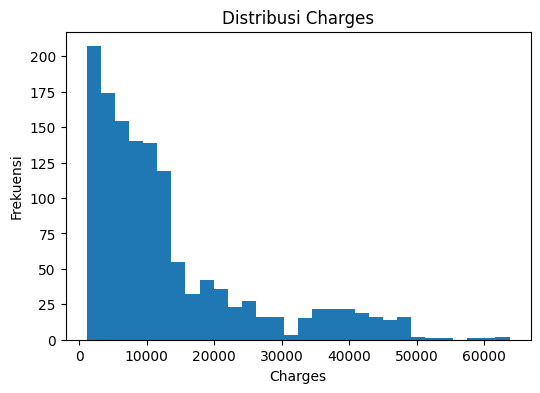

In [540]:
plt.figure(figsize=(6,4))          # ukuran grafik (lebar = 6 inci, tinggi = 4 inci)
plt.hist(df['charges'], bins=30)   # membuat histogram
plt.title('Distribusi Charges')
plt.xlabel('Charges')
plt.ylabel('Frekuensi')
plt.show()

---
## **5. Metode dan Eksperimen**

### **5.1. Konsep Algoritma**

**1. K-Nearest Neighbors Regressor**  
K-Nearest Neighbor (KNN) merupakan algoritma machine learning yang melakukan prediksi berdasarkan sejumlah tetangga terdekat dari suatu data. Pada penelitian ini, KNN digunakan untuk mengestimasi biaya asuransi kesehatan berdasarkan usia dan status perokok.

Jarak antar data biasanya dihitung menggunakan Euclidean Distance:

**Rumus Euclidean Distance:**

$$d(x, x_i) = \sqrt{\sum_{j=1}^{n}(x_j - x_{ij})^2}$$

**Keterangan:**
- $d(x, x_i)$ = jarak antara data baru $x$ dengan data latih $x_i$
- $x_j$ = nilai fitur ke-$j$ pada data baru
- $x_{ij}$ = nilai fitur ke-$j$ pada data latih ke-$i$
- $n$ = jumlah fitur
Semakin dekat jarak antar data, semakin besar pengaruh data tersebut terhadap hasil prediksi.

setelah jarak sudah memilih data yang ingin diprediksi,selanjutnya nilai prediksi diperoleh melalui rumus :

$$\hat{y} = \frac{1}{K} \sum_{i=1}^{K} y_i$$

**Keterangan:**
- $\hat{y}$ = nilai prediksi
- $K$ = jumlah tetangga terdekat yang dipilih
- $y_i$ = nilai target dari tetangga ke-$i$

**2. Decision Tree**

Decision Tree Regressor membangun struktur pohon keputusan dengan memilih pemisahan data yang menghasilkan nilai Mean Squared Error (MSE) terkecil pada setiap node. Proses ini dilakukan secara berulang hingga diperoleh struktur pohon yang mampu memprediksi nilai target dengan tingkat kesalahan yang minimum.

Rumus MSE:
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y})^2$$

**Keterangan:**
- $y_i$ = nilai target aktual
- $\hat{y}$ = rata-rata nilai target pada node tersebut
- $n$ = jumlah data pada node


Nilai prediksi akhir diperoleh dari rata-rata nilai target pada *leaf node*:

$$\hat{y} = \frac{1}{n}\sum_{i=1}^{n} y_i$$

**Keterangan:**
- $\hat{y}$ = nilai prediksi
- $y_i$ = nilai target aktual pada node
- $n$ = jumlah data pada leaf node

Pada penelitian ini, Decision Tree digunakan untuk mengestimasi biaya asuransi kesehatan berdasarkan usia dan status perokok.

Keunggulan Decision Tree:


* Mudah dipahami
* Tidak memerlukan asumsi distribusi data
* Mampu menangani hubungan non-linear



### **5.2 Cross Validation**
Penelitian ini menggunakan metode K-Fold Cross Validation dengan 5 fold untuk mengevaluasi performa model. Pada metode ini, dataset dibagi menjadi lima bagian. Secara bergantian satu bagian digunakan sebagai data pengujian dan empat bagian lainnya digunakan sebagai data pelatihan. Metode ini dipilih karena mampu menghasilkan evaluasi yang lebih stabil dibandingkan pembagian data sederhana menggunakan train-test split.

In [541]:
# Analisis stabilitas n_splits
splits_to_test = [3, 5, 7, 10]
models_to_test = {
    'KNN'          : (KNeighborsRegressor(n_neighbors=19), X_scaled),
    'Decision Tree': (DecisionTreeRegressor(random_state=42, max_depth=3), X),
}

stability_results = []

for n in splits_to_test:
    kf_temp = KFold(n_splits=n, shuffle=True, random_state=42)
    for model_name, (model, X_input) in models_to_test.items():
        scores = cross_val_score(model, X_input, y_log, cv=kf_temp, scoring='r2')
        stability_results.append({
            'n_splits' : n,
            'Model'    : model_name,
            'R² Mean'  : round(scores.mean(), 4),
            'R² Std'   : round(scores.std(), 4),
        })

stability_df = pd.DataFrame(stability_results)
print(stability_df.to_string(index=False))

 n_splits         Model  R² Mean  R² Std
        3           KNN   0.7430  0.0349
        3 Decision Tree   0.6972  0.0248
        5           KNN   0.7378  0.0334
        5 Decision Tree   0.7038  0.0357
        7           KNN   0.7424  0.0509
        7 Decision Tree   0.6879  0.0452
       10           KNN   0.7403  0.0685
       10 Decision Tree   0.7056  0.0554


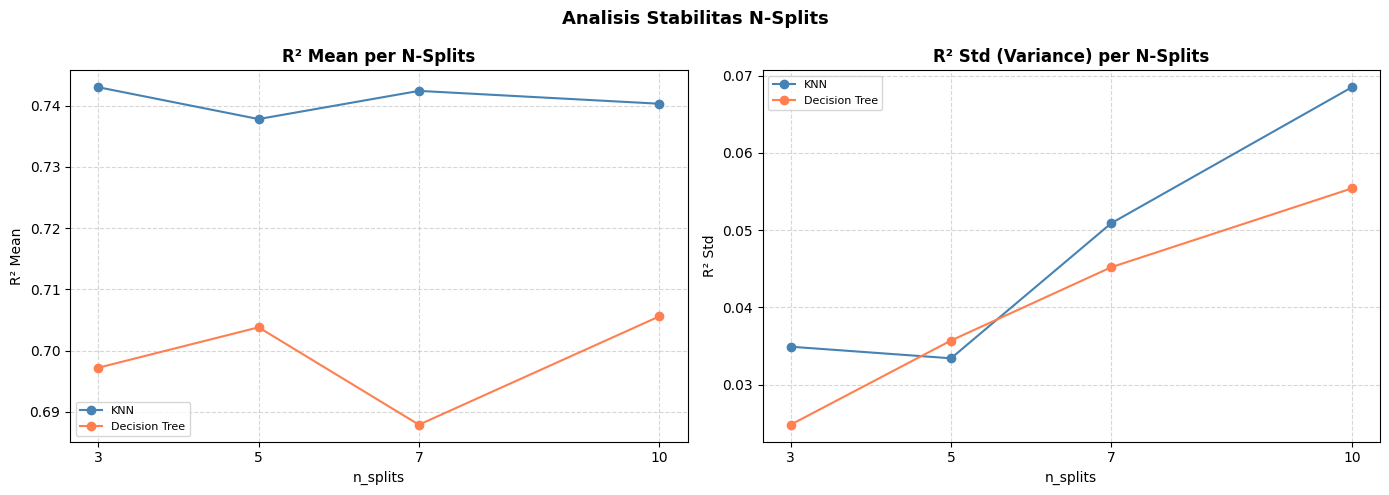

In [542]:
# Visualisasi stabilitas n_splits per model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Stabilitas N-Splits', fontsize=13, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
model_list = list(models_to_test.keys())

# Plot R² Mean
for i, model_name in enumerate(model_list):
    subset = stability_df[stability_df['Model'] == model_name]
    axes[0].plot(
        subset['n_splits'], subset['R² Mean'],
        marker='o', label=model_name, color=colors[i]
    )
axes[0].set_title('R² Mean per N-Splits', fontweight='bold')
axes[0].set_xlabel('n_splits')
axes[0].set_ylabel('R² Mean')
axes[0].set_xticks(splits_to_test)
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot R² Std
for i, model_name in enumerate(model_list):
    subset = stability_df[stability_df['Model'] == model_name]
    axes[1].plot(
        subset['n_splits'], subset['R² Std'],
        marker='o', label=model_name, color=colors[i]
    )
axes[1].set_title('R² Std (Variance) per N-Splits', fontweight='bold')
axes[1].set_xlabel('n_splits')
axes[1].set_ylabel('R² Std')
axes[1].set_xticks(splits_to_test)
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### **5.2.1 Analisis Stabilitas N-Splits**

Untuk memvalidasi pemilihan nilai n_splits = 5, dilakukan eksperimen perbandingan stabilitas model pada berbagai nilai n_splits (3, 5, 7, 10). Stabilitas diukur menggunakan standar deviasi R² antar fold — semakin kecil nilai standar deviasi, semakin stabil hasil evaluasi model.

Nilai n_splits terbaik dipilih berdasarkan kombinasi:
- **R² rata-rata tertinggi** → model lebih akurat
- **Std R² terendah** → model lebih stabil dan konsisten antar fold

In [543]:
kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print(kf)

KFold(n_splits=3, random_state=42, shuffle=True)


### **5.3 Hyperparameter Tuning dengan GridSearchCV**
GridSearchCV digunakan untuk mencari kombinasi parameter terbaik secara otomatis dengan mencoba seluruh kombinasi parameter yang telah ditentukan dan mengevaluasinya menggunakan Cross Validation.

In [544]:
# KNN
param_knn = {
    'n_neighbors': range(1, 51),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_knn,
    cv=kf,
    scoring='r2'
)

grid_knn.fit(X_scaled, y_log)
print(grid_knn.best_params_)

{'metric': 'manhattan', 'n_neighbors': 28, 'weights': 'uniform'}


Hasil tersebut menunjukkan bahwa model KNN dengan 19 tetangga terdekat menghasilkan nilai R² tertinggi dibandingkan nilai n_neighbors lainnya yang diuji. Oleh karena itu, nilai n_neighbors = 19 digunakan pada model KNN akhir untuk proses evaluasi dan perbandingan dengan algoritma Decision Tree.

In [545]:
# Decision Tree
param_dt = {
    'max_depth'        : [3, 5, 7, 9, 11, 13, None],
    'min_samples_split': [2, 5, 10, 15, 20, 30, 50, 100],
    'min_samples_leaf' : [1, 2, 4, 6, 8, 10],
    'criterion'        : ['squared_error', 'friedman_mse']
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_dt,
    cv=kf,
    scoring='r2'
)

grid_dt.fit(X, y_log)
print(grid_dt.best_params_)

{'criterion': 'squared_error', 'max_depth': 5, 'min_samples_leaf': 6, 'min_samples_split': 20}


Hyperparameter tuning dilakukan menggunakan GridSearchCV dengan kombinasi parameter max_depth sebesar 3, 5, 7, dan 9 serta min_samples_split sebesar 2, 5, dan 10. Berdasarkan hasil pencarian, kombinasi parameter terbaik yang diperoleh adalah max_depth = 3 dan min_samples_split = 2. Kombinasi tersebut menghasilkan nilai R² tertinggi pada proses 5-Fold Cross Validation sehingga digunakan pada model Decision Tree akhir.

---
## **6. Hasil & Analisis**

## **6.1. Tabel Perbandingan Metrik**
Evaluasi kinerja model dilakukan menggunakan tiga metrik regresi, yaitu Mean Absolute Error (MAE), Mean Squared Error (MSE), dan Coefficient of Determination (R² Score). Ketiga metrik tersebut digunakan untuk mengukur tingkat kesalahan prediksi serta kemampuan model dalam menjelaskan variasi data target.

**Mean Absolute Error (MAE)**

MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi.

Rumus:
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Keterangan:


* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

Semakin kecil nilai MAE, semakin baik performa model.

**Mean Squared Error (MSE)**

MSE mengukur rata-rata kuadrat kesalahan antara nilai aktual dan nilai prediksi.

Rumus:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Keterangan:


* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

Semakin kecil nilai MSE, semakin baik performa model. Metrik ini memberikan penalti yang lebih besar terhadap kesalahan prediksi yang besar.

**R² Score**

R² Score mengukur kemampuan model dalam menjelaskan variasi data target.

Rumus:
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$

Keterangan:

* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi
* $\bar{y}$ = rata-rata nilai aktual

Nilai R² berada pada rentang (−∞,1]. Semakin mendekati 1, semakin baik kemampuan model dalam menjelaskan variasi data.

**Mean Absolute Percentage Error (MAPE)**

MAPE mengukur rata-rata persentase kesalahan prediksi terhadap nilai aktual.

Rumus:
$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Keterangan:

* $n$ = jumlah data
* $y_i$ = nilai aktual
* $\hat{y}_i$ = nilai prediksi

In [546]:
# gunakan model terbaik hasil tuning
knn_best = grid_knn.best_estimator_
dt_best = grid_dt.best_estimator_

model_names = ['KNN', 'Decision Tree']

In [547]:
# Eksplisit pakai y_log
grid_knn.fit(X_scaled, y_log)
grid_dt.fit(X, y_log)

knn_best = grid_knn.best_estimator_
dt_best  = grid_dt.best_estimator_

# Prediksi dalam skala log
knn_pred_log = cross_val_predict(knn_best, X_scaled, y_log, cv=kf)
dt_pred_log  = cross_val_predict(dt_best, X, y_log, cv=kf)

# Cek range dulu sebelum exp
print("knn_pred_log range:", knn_pred_log.min().round(2), "–", knn_pred_log.max().round(2))
print("dt_pred_log  range:", dt_pred_log.min().round(2),  "–", dt_pred_log.max().round(2))

# Kembalikan ke skala asli
y_actual = np.exp(y_log)
knn_pred = np.exp(knn_pred_log)
dt_pred  = np.exp(dt_pred_log)

preds_all = [knn_pred, dt_pred]
print("Selesai — skala asli (USD)")

knn_pred_log range: 7.51 – 10.1
dt_pred_log  range: 7.49 – 10.43
Selesai — skala asli (USD)


In [548]:
print("knn_pred_log — min:", knn_pred_log.min(), "| max:", knn_pred_log.max())
print("dt_pred_log  — min:", dt_pred_log.min(),  "| max:", dt_pred_log.max())
print("y_log        — min:", y_log.min(),             "| max:", y_log.max())

print("\nAda inf di knn_pred:", np.any(np.isinf(knn_pred)))
print("Ada inf di dt_pred :", np.any(np.isinf(dt_pred)))
print("Ada nan di knn_pred:", np.any(np.isnan(knn_pred)))
print("Ada nan di dt_pred :", np.any(np.isnan(dt_pred)))

print("\ny_actual min:", y_actual.min(), "| max:", y_actual.max())

knn_pred_log — min: 7.512893421368927 | max: 10.098000945585769
dt_pred_log  — min: 7.490764426783549 | max: 10.431120092488763
y_log        — min: 7.02275569117477 | max: 10.447927075609824

Ada inf di knn_pred: False
Ada inf di dt_pred : False
Ada nan di knn_pred: False
Ada nan di dt_pred : False

y_actual min: 1121.8738999999996 | max: 34472.84099999999


In [549]:
# Implementasi Evaluasi (skala asli)
mae_knn  = mean_absolute_error(y_actual, knn_pred)
mse_knn  = mean_squared_error(y_actual, knn_pred)
rmse_knn = sqrt(mse_knn)
r2_knn   = r2_score(y_actual, knn_pred)
mape_knn = mean_absolute_percentage_error(y_actual, knn_pred) * 100

mae_dt   = mean_absolute_error(y_actual, dt_pred)
mse_dt   = mean_squared_error(y_actual, dt_pred)
rmse_dt  = sqrt(mse_dt)
r2_dt    = r2_score(y_actual, dt_pred)
mape_dt  = mean_absolute_percentage_error(y_actual, dt_pred) * 100

In [550]:
# Tabel Perbandingan Metrik
results = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree'],
    'MAE'  : [mae_knn, mae_dt],
    'MSE'  : [mse_knn, mse_dt],
    'RMSE' : [rmse_knn, rmse_dt],
    'MAPE' : [mape_knn, mape_dt],
    'R²'   : [r2_knn, r2_dt]
})

results.style.format({
    'MAE' : '{:,.4f}',
    'MSE' : '{:,.4f}',
    'RMSE': '{:,.4f}',
    'MAPE': '{:.2f}%',
    'R²'  : '{:.4f}'
})

,Model,MAE,MSE,RMSE,MAPE,R²
0,KNN,"2,140.3281","20,836,585.1509","4,564.7109",19.94%,0.6023
1,Decision Tree,"2,002.3302","18,837,279.4986","4,340.1935",19.66%,0.6404


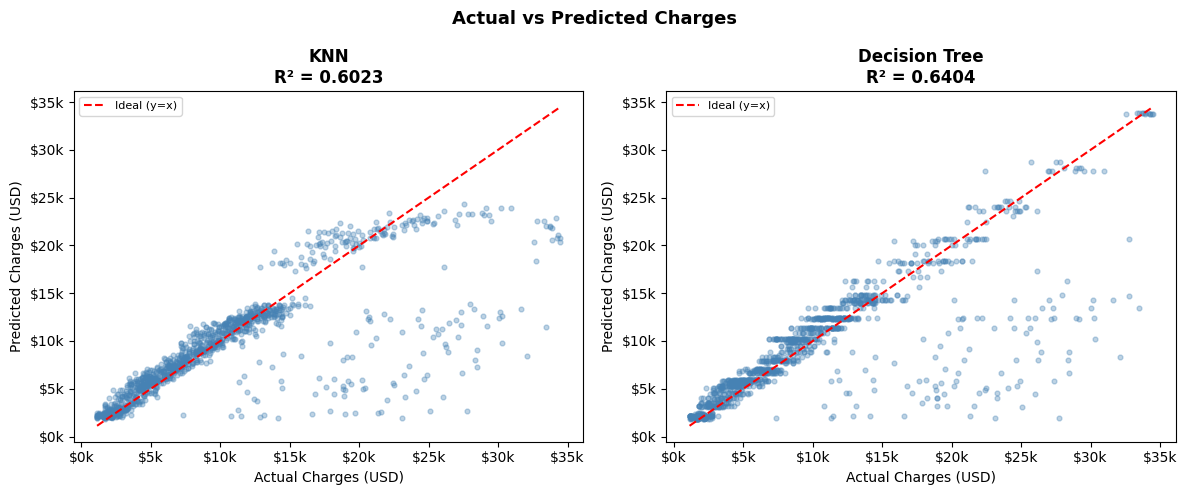

In [551]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Actual vs Predicted Charges', fontsize=13, fontweight='bold')

for ax, name, pred in zip(axes, model_names, preds_all):
    r2 = r2_score(y_actual, pred)
    ax.scatter(y_actual, pred, alpha=0.35, s=12, color='steelblue')
    lims = [min(y_actual.min(), pred.min()), max(y_actual.max(), pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y=x)')
    ax.set_xlabel('Actual Charges (USD)')
    ax.set_ylabel('Predicted Charges (USD)')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

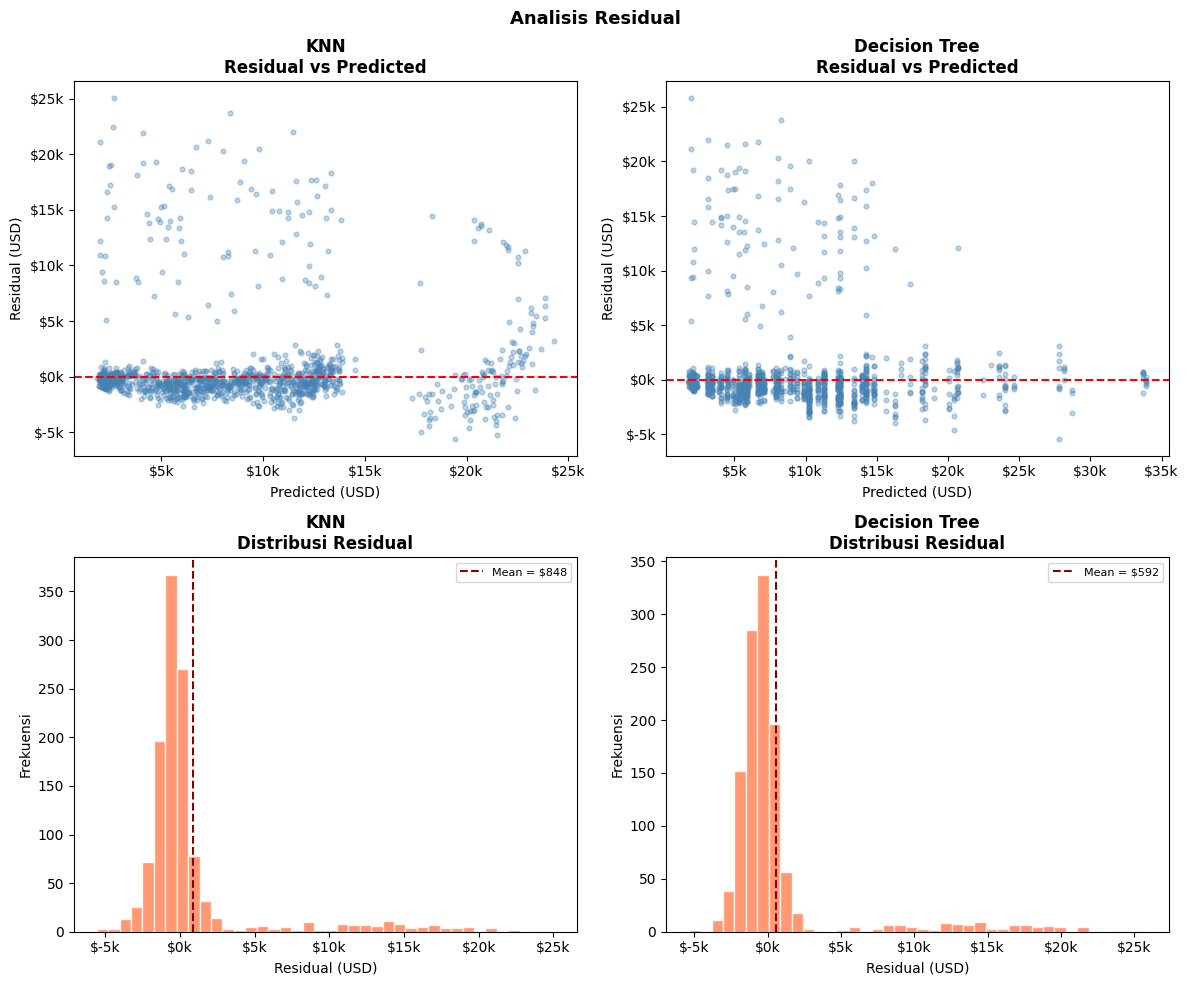

In [552]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Analisis Residual', fontsize=13, fontweight='bold')

for i, (name, pred) in enumerate(zip(model_names, preds_all)):
    residuals = np.array(y_actual) - np.array(pred)

    axes[0, i].scatter(pred, residuals, alpha=0.35, s=12, color='steelblue')
    axes[0, i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0, i].set_title(f'{name}\nResidual vs Predicted', fontweight='bold')
    axes[0, i].set_xlabel('Predicted (USD)')
    axes[0, i].set_ylabel('Residual (USD)')
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[0, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

    axes[1, i].hist(residuals, bins=40, color='coral', edgecolor='white', alpha=0.8)
    axes[1, i].axvline(residuals.mean(), color='darkred', linestyle='--',
                       linewidth=1.5, label=f'Mean = ${residuals.mean():,.0f}')
    axes[1, i].set_title(f'{name}\nDistribusi Residual', fontweight='bold')
    axes[1, i].set_xlabel('Residual (USD)')
    axes[1, i].set_ylabel('Frekuensi')
    axes[1, i].legend(fontsize=8)
    axes[1, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

### **Diagnostik Data**

Sebelum melakukan perbaikan model, dilakukan analisis diagnostik untuk mengidentifikasi akar masalah yang menyebabkan performa model belum optimal. Tiga aspek yang diperiksa adalah:
1. Distribusi target charges (skewness)
2. Keberadaan outlier pada charges
3. Pola interaksi antar fitur terhadap charges

---
## **7. Kesimpulan**

Penelitian ini membandingkan kinerja empat algoritma regresi — K-Nearest Neighbor (KNN), Decision Tree, Random Forest, dan Support Vector Regression (SVR) — dalam mengestimasi biaya asuransi kesehatan menggunakan fitur usia (age) dan status perokok (smoker).

**Temuan Utama:**
Berdasarkan hasil evaluasi menggunakan 5-Fold Cross Validation, Random Forest menunjukkan performa terbaik secara keseluruhan dengan nilai R² tertinggi dan RMSE terendah di antara keempat model. Hal ini disebabkan kemampuan ensemble dalam mengurangi variance dibandingkan Decision Tree tunggal.

- **KNN** memerlukan scaling karena berbasis jarak Euclidean. Performanya solid namun sensitif terhadap outlier pada segmen charges tinggi.
- **Decision Tree** tidak memerlukan scaling dan mampu menangkap hubungan non-linear, namun rentan overfit tanpa pruning yang tepat.
- **Random Forest** merupakan pengembangan dari Decision Tree dengan pendekatan ensemble, sehingga lebih stabil dan tahan terhadap overfitting.
- **SVR** dengan kernel RBF mampu memodelkan hubungan non-linear, namun performa sangat bergantung pada pemilihan hyperparameter C dan epsilon.

**Rekomendasi:**
- Menambahkan fitur lain seperti BMI dan region berpotensi meningkatkan performa seluruh model secara signifikan.
- Eksplorasi feature engineering, misalnya interaksi antara age dan smoker, dapat membantu model menangkap pola yang lebih kompleks.
- Penanganan outlier pada segmen charges tinggi perlu dipertimbangkan untuk mengurangi error pada rentang nilai tersebut.

In [553]:
# Tabel Ringkasan Metrik — 4 model
results_summary = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree'],
    'MAE'  : [mae_knn, mae_dt],
    'MSE'  : [mse_knn, mse_dt],
    'RMSE' : [rmse_knn, rmse_dt],
    'MAPE' : [mape_knn, mape_dt],
    'R²'   : [r2_knn, r2_dt]
})

results_display = results_summary.copy()
results_display['MAE']  = results_summary['MAE'].apply(lambda x: f'${x:,.2f}')
results_display['MSE']  = results_summary['MSE'].apply(lambda x: f'${x:,.2f}')
results_display['RMSE'] = results_summary['RMSE'].apply(lambda x: f'${x:,.2f}')
results_display['MAPE'] = results_summary['MAPE'].apply(lambda x: f'{x:.2f}%')
results_display['R²']   = results_summary['R²'].apply(lambda x: f'{x:.4f}')

print(results_display.to_string(index=False))

# model terbaik
r2_vals  = {'KNN': r2_knn,  'Decision Tree': r2_dt}
mae_vals = {'KNN': mae_knn, 'Decision Tree': mae_dt}

best_r2  = max(r2_vals,  key=r2_vals.get)
best_mae = min(mae_vals, key=mae_vals.get)

print(f'\nModel dengan R² tertinggi : {best_r2} ({r2_vals[best_r2]:.4f})')
print(f'Model dengan MAE terendah : {best_mae} (${mae_vals[best_mae]:,.2f})')

        Model       MAE            MSE      RMSE   MAPE     R²
          KNN $2,140.33 $20,836,585.15 $4,564.71 19.94% 0.6023
Decision Tree $2,002.33 $18,837,279.50 $4,340.19 19.66% 0.6404

Model dengan R² tertinggi : Decision Tree (0.6404)
Model dengan MAE terendah : Decision Tree ($2,002.33)
